
# GOOG Trading Strategy Comparison

## Objective

In this notebook we will compare two trading strategies using historical GOOG (Google) stock data downloaded from Yahoo Finance:

### Strategy 1: Buy and Hold
- Buy 100 shares on the first trading day.
- Hold the position throughout the entire period.
- Sell on the last trading day.
- This strategy represents a passive investor.

### Strategy 2: Random Trading Strategy
- Generate random trading signals (0 = out of market, 1 = invested).
- Use a fixed random seed to make results reproducible.
- Enter and exit positions based on signal changes.
- This strategy represents a trader making random decisions.

For both strategies we will:
1. Download GOOG historical data.
2. Generate signals.
3. Calculate orders.
4. Compute holdings value.
5. Compute cash balance.
6. Compute total portfolio value.
7. Compare final performance.
8. Visualize portfolio evolution.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import random

plt.style.use('default')



## Download Historical GOOG Data

We download daily GOOG prices between 2001 and 2018.


In [2]:

start_date = '2001-01-01'
end_date = '2018-01-01'

goog_data = yf.download(
    'GOOG',
    start=start_date,
    end=end_date,
    auto_adjust=True,
    multi_level_index=False
)

goog_data.head()


[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2004-08-19,2.477291,2.569133,2.369154,2.468896,897427216
2004-08-20,2.674063,2.693073,2.481242,2.493833,458857488
2004-08-23,2.700973,2.801704,2.692332,2.734303,366857939
2004-08-24,2.589133,2.755289,2.557037,2.746401,306396159
2004-08-25,2.617030,2.666409,2.564690,2.591354,184645512


In [3]:

close_price = goog_data['Close']
close_price.head()


Date
2004-08-19    2.477291
2004-08-20    2.674063
2004-08-23    2.700973
2004-08-24    2.589133
2004-08-25    2.617030
Name: Close, dtype: float64


## Strategy 1 - Buy and Hold

The investor purchases 100 shares on the first trading day and keeps them until the end.


In [4]:

buy_hold = pd.DataFrame(index=goog_data.index)

buy_hold['signal'] = 1
buy_hold.iloc[-1, buy_hold.columns.get_loc('signal')] = 0

buy_hold['orders'] = buy_hold['signal'].diff()

buy_hold.head()


,signal,orders
Date,,
2004-08-19,1,NaN
2004-08-20,1,0.0
2004-08-23,1,0.0
2004-08-24,1,0.0
2004-08-25,1,0.0


In [5]:

initial_capital = 10000

buy_hold['position'] = buy_hold['signal'] * 100

buy_hold['holdings'] = buy_hold['position'] * close_price

trade_value = buy_hold['orders'] * 100 * close_price

buy_hold['cash'] = initial_capital - trade_value.cumsum().fillna(0)

buy_hold['total'] = buy_hold['cash'] + buy_hold['holdings']

buy_hold.tail()


,signal,orders,position,holdings,cash,total
Date,,,,,,
2017-12-22,1,0.0,100,5254.274368,10000.000000,15254.274368
2017-12-26,1,0.0,100,5237.522507,10000.000000,15237.522507
2017-12-27,1,0.0,100,5200.993729,10000.000000,15200.993729
2017-12-28,1,0.0,100,5194.897842,10000.000000,15194.897842
2017-12-29,0,-1.0,0,0.000000,15186.273956,15186.273956



### Buy and Hold Orders


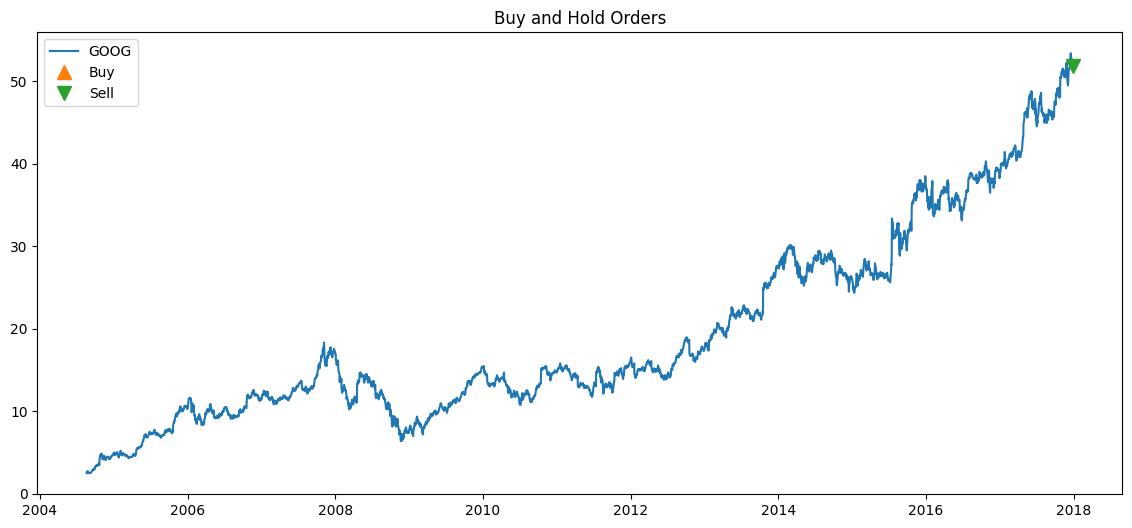

In [6]:

fig, ax = plt.subplots(figsize=(14,6))

ax.plot(close_price.index, close_price, label='GOOG')

ax.plot(
    buy_hold.loc[buy_hold['orders']==1].index,
    close_price.loc[buy_hold['orders']==1],
    '^',
    markersize=10,
    label='Buy'
)

ax.plot(
    buy_hold.loc[buy_hold['orders']==-1].index,
    close_price.loc[buy_hold['orders']==-1],
    'v',
    markersize=10,
    label='Sell'
)

ax.set_title('Buy and Hold Orders')
ax.legend()
plt.show()



## Strategy 2 - Random Trading Strategy

Random signals are generated using a fixed seed so that everyone obtains identical results.


In [7]:

random.seed(6666)

signals = pd.DataFrame(index=goog_data.index)

signals['signal'] = [
    random.randint(0,1)
    for _ in range(len(signals))
]

signals['orders'] = signals['signal'].diff()

signals.head()


,signal,orders
Date,,
2004-08-19,0,NaN
2004-08-20,0,0.0
2004-08-23,0,0.0
2004-08-24,1,1.0
2004-08-25,1,0.0


In [8]:

random_portfolio = pd.DataFrame(index=goog_data.index)

random_portfolio['signal'] = signals['signal']
random_portfolio['orders'] = signals['orders']
random_portfolio['position'] = random_portfolio['signal'] * 100

random_portfolio['holdings'] = (
    random_portfolio['position'] * close_price
)

trade_value = (
    random_portfolio['orders'] * 100 * close_price
)

random_portfolio['cash'] = (
    initial_capital - trade_value.cumsum().fillna(0)
)

random_portfolio['total'] = (
    random_portfolio['cash'] +
    random_portfolio['holdings']
)

random_portfolio.tail()


,signal,orders,position,holdings,cash,total
Date,,,,,,
2017-12-22,0,-1.0,0,0.000000,12690.522742,12690.522742
2017-12-26,1,1.0,100,5237.522507,7453.000236,12690.522742
2017-12-27,0,-1.0,0,0.000000,12653.993964,12653.993964
2017-12-28,1,1.0,100,5194.897842,7459.096122,12653.993964
2017-12-29,1,0.0,100,5186.273956,7459.096122,12645.370078


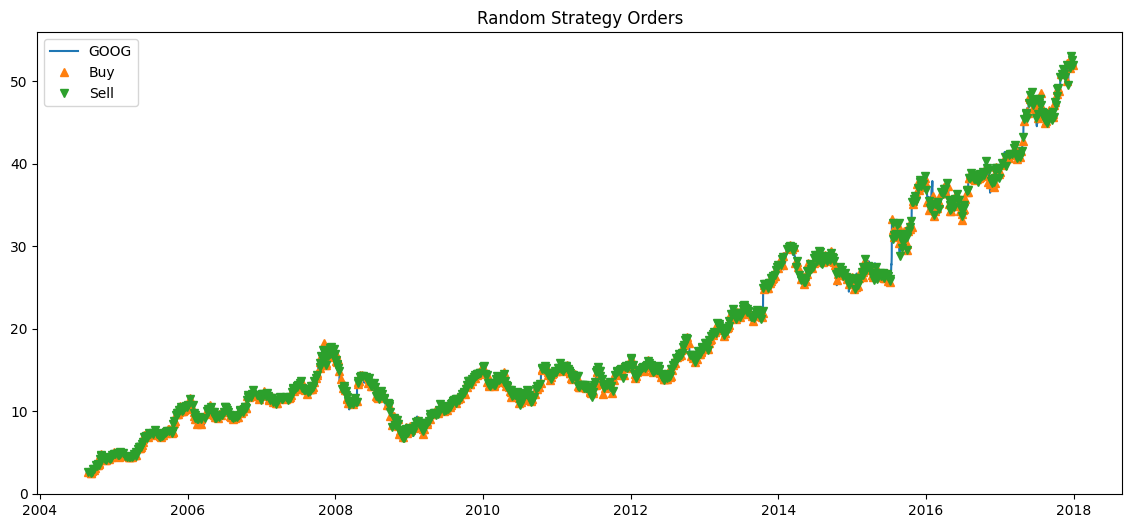

In [9]:

fig, ax = plt.subplots(figsize=(14,6))

ax.plot(close_price.index, close_price, label='GOOG')

ax.plot(
    signals.loc[signals['orders']==1].index,
    close_price.loc[signals['orders']==1],
    '^',
    markersize=6,
    label='Buy'
)

ax.plot(
    signals.loc[signals['orders']==-1].index,
    close_price.loc[signals['orders']==-1],
    'v',
    markersize=6,
    label='Sell'
)

ax.set_title('Random Strategy Orders')
ax.legend()
plt.show()



## Compare Portfolio Values


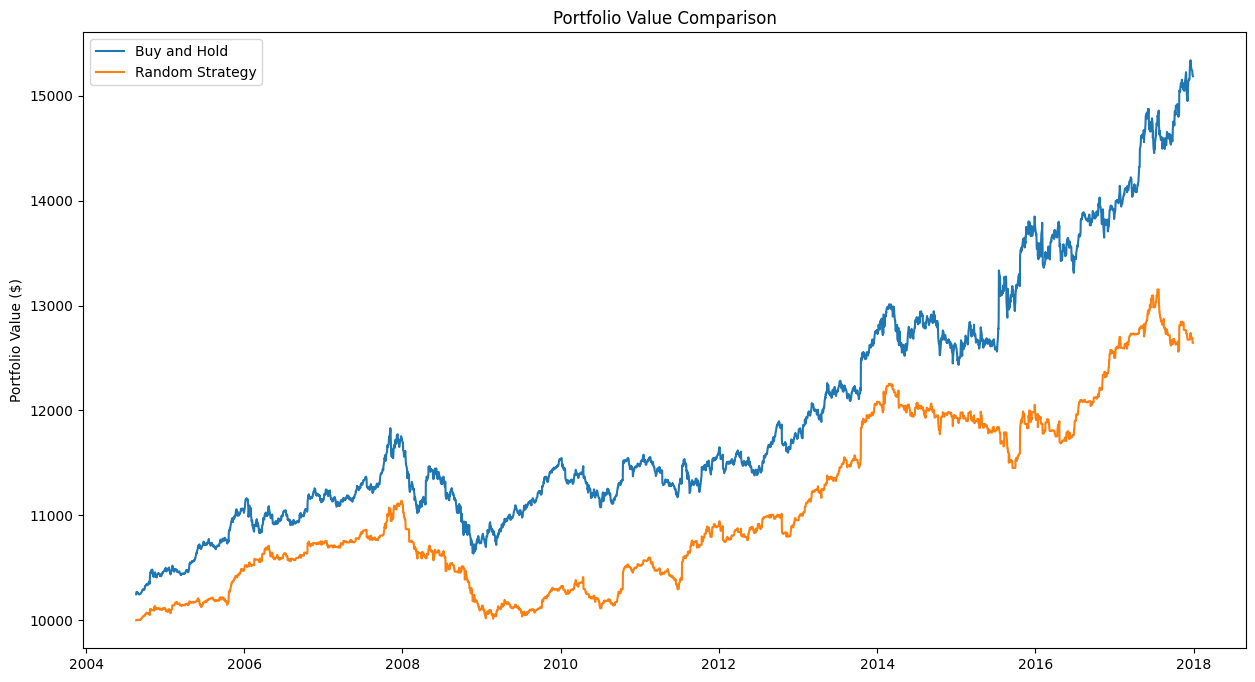

In [10]:

fig, ax = plt.subplots(figsize=(15,8))

ax.plot(
    buy_hold.index,
    buy_hold['total'],
    label='Buy and Hold'
)

ax.plot(
    random_portfolio.index,
    random_portfolio['total'],
    label='Random Strategy'
)

ax.set_title('Portfolio Value Comparison')
ax.set_ylabel('Portfolio Value ($)')
ax.legend()

plt.show()


In [11]:

comparison = pd.DataFrame({
    'Buy and Hold': [buy_hold['total'].iloc[-1]],
    'Random Strategy': [random_portfolio['total'].iloc[-1]]
})

comparison.index = ['Final Portfolio Value']

comparison


,Buy and Hold,Random Strategy
Final Portfolio Value,15186.273956,12645.370078



## Conclusion

The Buy-and-Hold strategy remains invested during the entire period and fully benefits from GOOG's long-term appreciation.

The Random Strategy frequently enters and exits the market based on random decisions. Because the decisions are not based on information or analysis, performance can differ significantly from the Buy-and-Hold strategy.

This exercise illustrates how different trading rules can lead to dramatically different portfolio outcomes even when applied to the same market data.
